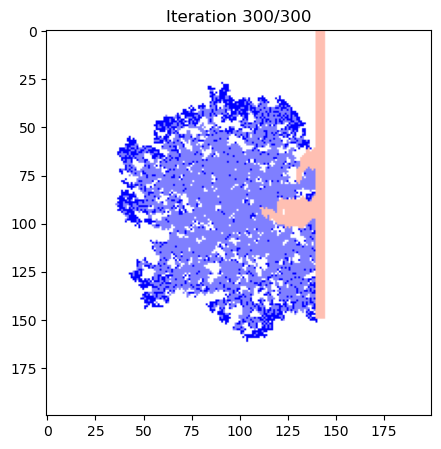

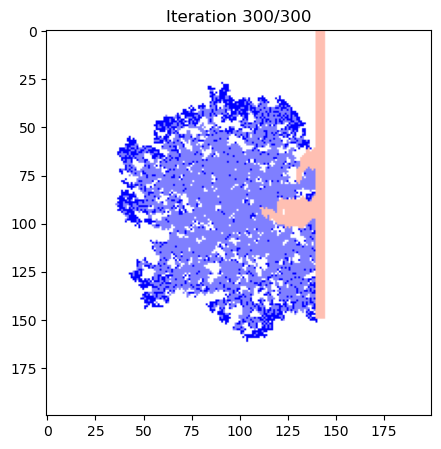

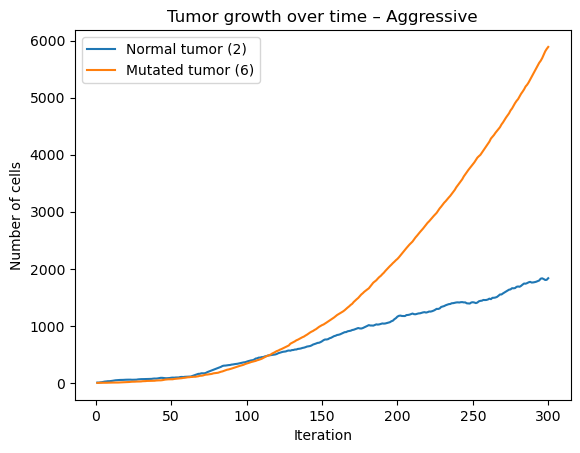

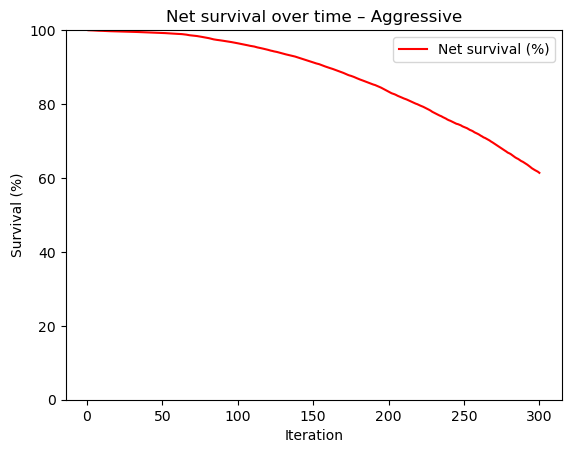

In [5]:
"""
Tumor Growth Cellular Automaton (Python translation of MATLAB `camodel.m`)
--------------------------------------------------------------------------
This script is designed to be run in a Jupyter notebook.
It follows the logic described in the original MATLAB version:
- 2D grid of tissue
- central tumor seed
- single vertical vessel that can break and sprout toward tumor
- tumor growth, mutation, optional drug, metastasis
- basic plotting of the grid and growth curves

Requirements:
    numpy
    matplotlib
    scipy  (for gaussian_filter)

In a notebook, just do:

    from tumor_simulation import all_conditions, camodel

    params = all_conditions("DrugTreatment")
    camodel(*params)

"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from matplotlib.colors import ListedColormap
import os


# ---------------------------------------------------------------------
# 1) conditions.m  -->  all_conditions() in Python
# ---------------------------------------------------------------------
def all_conditions(condition_name: str):
    """
    Python version of the MATLAB file:

        function macroParam = all_conditions(conditionName)
            switch conditionName
                case 'Control'
                    macroParam = [0.001, 0.055, 0.95, 0.02, 0.0002];
                ...

    Returns:
        (break_threshold, tumor_chance, death_chance, mutation_chance, metastasis_chance)
    """
    name = condition_name.strip()

    if name == "Control":
        # [breakThreshold, tumorChance, deathChance, mutationChance, metastasisChance]
        return (0.001, 0.055, 0.95, 0.02, 0.0002)
    elif name == "Aggressive":
        return (0.001, 0.065, 0.95, 0.025, 0.0004)
    elif name == "DrugTreatment":
        return (0.001, 0.025, 0.95, 0.01, 0.0001)
    else:
        raise ValueError(f"Unknown condition name: {condition_name!r}")


# ---------------------------------------------------------------------
# 2) helper: survival model (direct port of the MATLAB helper)
# ---------------------------------------------------------------------
def calculate_survival(total_tumor_cells: int) -> float:
    """
    Linear survival drop: 100% --> 0% as tumor cells --> 20_000
    """
    initial_survival_rate = 100.0
    max_tumor_cells = 20_000.0
    net_survival = initial_survival_rate * (1.0 - total_tumor_cells / max_tumor_cells)
    if net_survival < 0:
        net_survival = 0.0
    return net_survival


# ---------------------------------------------------------------------
# 3) main cellular automaton
# ---------------------------------------------------------------------
from IPython.display import clear_output, display

def camodel(
    break_threshold: float,
    tumor_chance: float,
    death_chance: float,
    mutation_chance: float,
    metastasis_chance: float,
    grid_size: int = 200,
    num_iterations: int = 300,
    show_plots: bool = True,
    condition_name: str = "Unknown",   # <-- NEW
):

    # --- same params as before ---
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.ndimage import gaussian_filter

    initial_tumor_size = 2
    neighborhood_size = 1
    vessel_humanizer = 0.5
    grow_chance = 1.0
    min_tumor_cell_count_for_metastasis = 50
    treatment_time = []

    grid = np.ones((grid_size, grid_size), dtype=np.int32)

    center = (grid_size // 2, grid_size // 2)
    yy, xx = np.meshgrid(np.arange(grid_size), np.arange(grid_size), indexing="ij")
    radius_sq = (initial_tumor_size / 2.0) ** 2
    circ_mask = (xx - center[1]) ** 2 + (yy - center[0]) ** 2 <= radius_sq
    grid[circ_mask] = 2

    vessel_width = 5
    vessel_height = 150
    start_row = 0
    start_col = 140
    vessel_mask = np.zeros_like(grid, dtype=bool)
    vessel_mask[start_row:start_row+vessel_height,
                start_col:start_col+vessel_width] = True
    grid[vessel_mask] = 5

    rng = np.random.default_rng(1234)
    raw_map = rng.random((grid_size, grid_size))
    raw_map = gaussian_filter(raw_map, sigma=1)
    mn, mx = raw_map.min(), raw_map.max()
    polarized = ((raw_map - mn) / (mx - mn)) ** 2

    growth_rate_map = np.zeros_like(polarized)
    growth_rate_map[polarized <= 0.3] = 1.0
    growth_rate_map[(polarized > 0.3) & (polarized <= 0.6)] = 0.02
    growth_rate_map[polarized > 0.6] = 0.02

    adjusted_tumor_chance = tumor_chance * growth_rate_map

    normal_tumor_count = np.zeros(num_iterations, dtype=int)
    mutated_tumor_count = np.zeros(num_iterations, dtype=int)
    net_survival = np.zeros(num_iterations, dtype=float)

    number_of_breaks = 0
    max_distance = abs(center[1] - start_col) or 1
    metastasis_flag = False

    d = np.arange(-neighborhood_size, neighborhood_size + 1)
    dy, dx = np.meshgrid(d, d, indexing="ij")
    neigh_offsets = np.stack([dy.ravel(), dx.ravel()], axis=1)
    neigh_offsets = neigh_offsets[~((neigh_offsets[:, 0] == 0) & (neigh_offsets[:, 1] == 0))]

    if show_plots:
        fig, ax = plt.subplots(figsize=(5, 5))

        # MATLAB-style colormap (same order as your MATLAB code)
        matlab_cmap = ListedColormap([
            (1.0, 1.0, 1.0),      # 1 normal / background
            (0.0, 0.0, 1.0),      # 2 tumor
            (1.0, 0.75, 0.7),     # 3 grown vessel
            (0.5, 0.0, 0.0),      # 4 sprouting vessel
            (1.0, 0.75, 0.7),     # 5 original vessel
            (0.5, 0.5, 1.0),      # 6 mutated tumor
        ])
        
    os.makedirs("snapshots", exist_ok=True)    


    for it in range(num_iterations):
        new_grid = grid.copy()
        grow_mask = np.zeros_like(grid, dtype=bool)

        for i in range(grid_size):
            for j in range(grid_size):
                cell_val = grid[i, j]

                # tumor growth
                if cell_val in (2, 6):
                    for off in neigh_offsets:
                        ni, nj = i + off[0], j + off[1]
                        if 0 <= ni < grid_size and 0 <= nj < grid_size and grid[ni, nj] == 1:
                            # check vessel adjacency
                            adj = False
                            for off2 in neigh_offsets:
                                vi, vj = ni + off2[0], nj + off2[1]
                                if 0 <= vi < grid_size and 0 <= vj < grid_size:
                                    if grid[vi, vj] in (3, 5):
                                        adj = True
                                        break
                            gch = adjusted_tumor_chance[ni, nj] * (1.5 if adj else 1.0)
                            if rng.random() <= gch:
                                grow_mask[ni, nj] = True

                # local 3x3
                i0, i1 = max(0, i-1), min(grid_size, i+2)
                j0, j1 = max(0, j-1), min(grid_size, j+2)
                local_patch = grid[i0:i1, j0:j1]
                empty_space = np.sum(local_patch == 1)
                tumor_count = np.sum((local_patch == 2) | (local_patch == 6))

                # vessel break → sprout
                if cell_val == 5 and empty_space != 0 and (40 < i < 160):
                    if number_of_breaks == 0 and rng.random() <= break_threshold:
                        new_grid[i, j] = 4
                        number_of_breaks += 1
                    else:
                        if number_of_breaks > 0:
                            reduced_p = break_threshold / (10.0 * number_of_breaks)
                            if rng.random() <= reduced_p:
                                new_grid[i, j] = 4
                                number_of_breaks += 1

                # sprout movement
                if cell_val == 4 and tumor_count == 0:
                    tumor_locs = np.argwhere((grid == 2) | (grid == 6))
                    if tumor_locs.size > 0:
                        dists = np.sqrt((tumor_locs[:, 0] - i)**2 +
                                        (tumor_locs[:, 1] - j)**2)
                        idx = np.argmin(dists)
                        ta, tb = tumor_locs[idx]
                    else:
                        ta, tb = i, j

                    best_dist = 1e30
                    grow_c, grow_d = i, j
                    for ci in range(i-1, i+2):
                        for cj in range(j-1, j+2):
                            if 0 <= ci < grid_size and 0 <= cj < grid_size:
                                dtmp = np.sqrt((ci - ta)**2 + (cj - tb)**2)
                                if dtmp < best_dist:
                                    best_dist = dtmp
                                    grow_c, grow_d = ci, cj

                    if rng.random() <= vessel_humanizer:
                        grow_c = np.clip(i + rng.integers(-1, 2), 0, grid_size-1)
                        grow_d = np.clip(j + rng.integers(-1, 2), 0, grid_size-1)

                    bv_width = int(5 * abs(j - center[1]) / max_distance)
                    for w in range(-bv_width, bv_width + 1):
                        ii = i + w
                        if 0 <= ii < grid_size:
                            new_grid[ii, j] = 3

                    new_grid[grow_c, grow_d] = 4

                # sprout touched tumor
                if cell_val == 4 and tumor_count != 0:
                    new_grid[i, j] = 3
                    metastasis_flag = True

        # apply growth
        new_grid[grow_mask] = 2

        # mutation
        mut_rand = rng.random((grid_size, grid_size))
        mutate_mask = (grid == 2) & (mut_rand <= mutation_chance)
        new_grid[mutate_mask] = 6

        # drug
        if it in treatment_time:
            death_rand = rng.random((grid_size, grid_size))
            death_mask = ((grid == 2) & (death_rand <= death_chance)) | (
                (grid == 6) & (death_rand <= death_chance/2.0)
            )
            new_grid[death_mask] = 1

        # metastasis
        total_tumor_now = np.sum((grid == 2) | (grid == 6))
        if total_tumor_now >= min_tumor_cell_count_for_metastasis and metastasis_flag:
            vessel_cells = np.argwhere((grid == 3) | (grid == 5))
            if vessel_cells.size > 0:
                num_sites = rng.integers(1, 4)
                for _ in range(num_sites):
                    vr, vc = vessel_cells[rng.integers(0, vessel_cells.shape[0])]
                    for off in neigh_offsets:
                        nr, nc = vr + off[0], vc + off[1]
                        if 0 <= nr < grid_size and 0 <= nc < grid_size:
                            if new_grid[nr, nc] == 1 and rng.random() <= metastasis_chance:
                                new_grid[nr, nc] = 2
                                break

        grid = new_grid

        normal_tumor_count[it] = np.sum(grid == 2)
        mutated_tumor_count[it] = np.sum(grid == 6)
        total_cells = normal_tumor_count[it] + mutated_tumor_count[it]
        net_survival[it] = max(0.0, 100.0 * (1 - total_cells / 20000.0))

        # final plots (static)
        if show_plots:
            clear_output(wait=True)
            ax.imshow(grid, vmin=1, vmax=6, cmap=matlab_cmap)
            ax.set_title(f"Iteration {it+1}/{num_iterations}")
            display(fig)

            # --- THIS is the robust save block ---
            step = it + 1

            if step == 100:
                fname = f"snapshots/{condition_name}_iter_100.png"
                fig.savefig(fname, dpi=150, bbox_inches="tight")

            elif step == 200:
                fname = f"snapshots/{condition_name}_iter_200.png"
                fig.savefig(fname, dpi=150, bbox_inches="tight")

            elif step == 300:
                fname = f"snapshots/{condition_name}_iter_300.png"
                fig.savefig(fname, dpi=150, bbox_inches="tight")

            
    # 1) tumor counts
    plt.figure()
    x = np.arange(1, num_iterations + 1)
    plt.plot(x, normal_tumor_count, label="Normal tumor (2)")
    plt.plot(x, mutated_tumor_count, label="Mutated tumor (6)")
    plt.xlabel("Iteration")
    plt.ylabel("Number of cells")
    plt.title(f"Tumor growth over time – {condition_name}")
    plt.legend()

    # 2) survival plot (NEW)
    plt.figure()
    plt.plot(x, net_survival, label="Net survival (%)", color="red")
    plt.ylim(0, 100)
    plt.xlabel("Iteration")
    plt.ylabel("Survival (%)")
    plt.title(f"Net survival over time – {condition_name}")
    plt.legend()
    plt.show()            

# ---------------------------------------------------------------------
# run directly (optional)
# ---------------------------------------------------------------------
if __name__ == "__main__":
    cond = "Aggressive"
    params = all_conditions(cond)
    camodel(*params, show_plots=True, condition_name=cond)

